# 06. Classic ML cho Ph?n t?ch C?m x?c ?a kh?a c?nh (ABSA) - D? li?u interim/raw - Ti?ng Vi?t

Notebook n?y s? d?ng Machine Learning truy?n th?ng ?? gi?i quy?t 2 b?i to?n:
1. **Ph?n lo?i c?m x?c t?ng th?** (Overall Sentiment): Ti?u c?c (0) / Trung l?p (1) / T?ch c?c (2)
2. **Ph?n lo?i c?m x?c theo kh?a c?nh** (Aspect Sentiment): 6 kh?a c?nh ? {Ti?u c?c / Trung l?p / T?ch c?c / Kh?ng ?? c?p}

> **L?u ? quan tr?ng**: Nh?n **Trung l?p (Neutral)** trong dataset = **v?a khen v?a ch?** (mixed sentiment),
> kh?ng ph?i "kh?ng c? ? ki?n". ?i?u n?y ?nh h??ng tr?c ti?p ??n chi?n l??c feature engineering.

**C?c k? thu?t ch?nh:**
- T?ch t? ti?ng Vi?t b?ng `pyvi`
- Feature engineering: contrastive markers, mixed sentiment detection, aspect lexicon
- TF-IDF v?i c?u h?nh ri?ng cho Overall vs. Aspect
- X? l? m?t c?n b?ng d? li?u: `class_weight` tu? ch?nh, neutral threshold tuning


In [47]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix, hstack
from IPython.display import display
from pyvi import ViTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
)

# ── Cấu hình chung ──
SEED = 42
np.random.seed(SEED)

PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"D:/DataPreprocessing/DoAn2"),
]
PROJECT_ROOT = next(
    (p for p in PROJECT_ROOT_CANDIDATES if (p / "data" / "interim" / "raw_train" / "train.json").exists()),
    Path.cwd(),
)

DATA_DIR = PROJECT_ROOT / "data" / "interim"
TRAIN_PATH = DATA_DIR / "raw_train" / "train.json"
VAL_PATH = DATA_DIR / "raw_val" / "val.json"
TEST_PATH = DATA_DIR / "raw_test" / "test.json"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "classic_ml_absa_raw_v1"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TEXT_COL = "content"
SENT_COL = "sentiment_llm"
ASPECT_COLS = ["as_content", "as_physical", "as_price", "as_packaging", "as_delivery", "as_service"]
ASPECT_NAMES = {
    "as_content": "content", "as_physical": "physical", "as_price": "price",
    "as_packaging": "packaging", "as_delivery": "delivery", "as_service": "service",
}

SENTIMENT_ID_TO_TEXT = {0: "neg", 1: "neu", 2: "pos"}
SENTIMENT_LABELS = ["neg", "neu", "pos"]
ASPECT_LABELS = ["neg", "neu", "pos", "absent"]

# ── Cấu hình TF-IDF riêng cho từng bài toán ──
TFIDF_OVERALL_CONFIG = {
    "ngram_range": (1, 2),
    "max_features": 30000,
    "sublinear_tf": True,
    "min_df": 2,
    "max_df": 0.95,
    "tokenizer": str.split,
    "token_pattern": None,
}
TFIDF_OVERALL_CHAR_CONFIG = {
    "analyzer": "char_wb",
    "ngram_range": (3, 5),
    "max_features": 25000,
    "sublinear_tf": True,
    "min_df": 2,
    "max_df": 0.95,
}
TFIDF_ASPECT_CONFIG = {
    "ngram_range": (1, 2),
    "max_features": 30000,
    "sublinear_tf": True,
    "min_df": 1,
    "max_df": 0.95,
    "tokenizer": str.split,
    "token_pattern": None,
}
TFIDF_ASPECT_CHAR_CONFIG = {
    "analyzer": "char_wb",
    "ngram_range": (3, 5),
    "max_features": 25000,
    "sublinear_tf": True,
    "min_df": 2,
    "max_df": 0.95,
}

# ── Từ điển cho Feature Engineering ──
# Từ positive phổ biến (đã tách từ pyvi)
POS_WORDS = {
    "hay", "đẹp", "tốt", "nhanh", "thích", "ổn", "chất_lượng", "tuyệt", "tuyệt_vời",
    "hài_lòng", "xuất_sắc", "hoàn_hảo", "ưng", "yêu", "đáng_tiền", "rẻ", "giá_rẻ",
    "nhanh_chóng", "cẩn_thận", "chắc_chắn", "đáng_đọc", "bổ_ích",
}
# Từ negative phổ biến
NEG_WORDS = {
    "xấu", "chậm", "nhàu", "rách", "tệ", "lỗi", "méo", "mờ", "bẩn", "hỏng",
    "thất_vọng", "tồi", "kém", "dở", "nhạt", "sai", "chán", "đắt", "mắc",
    "trễ", "muộn", "hư", "mỏng", "bong", "tróc", "nhòe", "gãy",
}
# Từ trung lập / hedging
NEUTRAL_WORDS = {
    "tạm", "tạm_được", "cũng_ổn", "bình_thường", "tạm_ổn", "được",
    "cũng_được", "không_tệ", "chấp_nhận", "vừa_phải", "hơi",
}
# Từ đối lập (contrastive markers) – dấu hiệu #1 của mixed sentiment
CONTRASTIVE_WORDS = {
    "nhưng", "tuy_nhiên", "tuy", "mặc_dù", "dù", "song", "thế_nhưng",
    "tuy_vậy", "bù_lại", "nhưng_mà", "trừ", "ngoại_trừ",
}
# Từ nhấn mạnh (intensifiers) – cảm xúc mạnh = không neutral
INTENSIFIER_WORDS = {
    "rất", "quá", "cực_kỳ", "vô_cùng", "siêu", "tuyệt_đối",
    "hết_sức", "vô_cùng", "cực", "khá",
}
# Từ khóa cho từng aspect
ASPECT_LEXICONS = {
    "content": {"nội_dung", "cốt_truyện", "chương", "dịch", "dịch_thuật", "văn_phong", "kiến_thức", "bài_học", "câu_chuyện", "tác_giả"},
    "physical": {"bìa", "giấy", "in_ấn", "gáy", "mực", "bookmark", "bìa_cứng", "bìa_mềm", "khổ", "trang"},
    "price": {"giá", "tiền", "đắt", "rẻ", "sale", "đáng_tiền", "giá_cả", "giảm_giá", "mắc", "phí"},
    "packaging": {"đóng_gói", "hộp", "bọc", "chống_sốc", "bubble", "gói", "bao_bì", "nilon", "carton", "móp"},
    "delivery": {"giao_hàng", "giao", "shipper", "vận_chuyển", "ship", "tốc_độ", "ngày", "freeship", "giao_nhanh"},
    "service": {"tư_vấn", "đổi_trả", "thái_độ", "shop", "tiki", "fahasa", "nhân_viên", "hỗ_trợ", "phục_vụ", "chăm_sóc"},
}


def normalize_lexicon_text(text):
    return " ".join(str(text).lower().replace("_", " ").split())


def count_lexicon_hits(text, terms):
    normalized_text = f" {normalize_lexicon_text(text)} "
    return sum(
        1
        for term in terms
        if f" {normalize_lexicon_text(term)} " in normalized_text
    )


def has_any_lexicon_term(text, terms):
    normalized_text = f" {normalize_lexicon_text(text)} "
    return int(
        any(
            f" {normalize_lexicon_text(term)} " in normalized_text
            for term in terms
        )
    )


def bin_review_length(word_count):
    if word_count < 5:
        return 0
    if word_count <= 20:
        return 1
    if word_count <= 50:
        return 2
    return 3


sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

print("Project root:", PROJECT_ROOT)
print("Train:", TRAIN_PATH)
print("Val:", VAL_PATH)
print("Test:", TEST_PATH)


Project root: d:\DataPreprocessing\DoAn2
Train: d:\DataPreprocessing\DoAn2\data\interim\raw_train\train.json
Val: d:\DataPreprocessing\DoAn2\data\interim\raw_val\val.json
Test: d:\DataPreprocessing\DoAn2\data\interim\raw_test\test.json


## 2. N?p d? li?u v? Ph?n t?ch ph?n b?

D? li?u n?m trong `data/interim/raw_train`, `data/interim/raw_val`, `data/interim/raw_test`. Notebook s? n?p tr?c ti?p c?c file JSON n?y v? xem ph?n b? nh?n ?? hi?u m?c ?? m?t c?n b?ng.

In [48]:
df_train = pd.read_json(TRAIN_PATH)
df_val = pd.read_json(VAL_PATH)
df_test = pd.read_json(TEST_PATH)

print(f"Train: {df_train.shape}  Val: {df_val.shape}  Test: {df_test.shape}")

# ── Phân bố cảm xúc tổng thể ──
sent_vc = df_train[SENT_COL].value_counts().sort_index()
sent_dist = pd.DataFrame({
    "label_id": sent_vc.index.astype(int),
    "label": [SENTIMENT_ID_TO_TEXT[int(i)] for i in sent_vc.index],
    "count": sent_vc.values,
})
sent_dist["percent"] = (sent_dist["count"] / sent_dist["count"].sum() * 100).round(2)
print("\n=== Phân bố cảm xúc tổng thể (train) ===")
display(sent_dist)

# ── Phân bố aspect ──
print("\n=== Phân bố aspect (train) ===")
for col in ASPECT_COLS:
    n_present = df_train[col].notna().sum()
    pct = round(n_present / len(df_train) * 100, 1)
    print(f"  {ASPECT_NAMES[col]:>12s}: {n_present:>5d} present ({pct}%)")


Train: (9392, 15)  Val: (2010, 15)  Test: (2009, 15)

=== Phân bố cảm xúc tổng thể (train) ===


,label_id,label,count,percent
0,0,neg,4922,52.41
1,1,neu,1532,16.31
2,2,pos,2938,31.28



=== Phân bố aspect (train) ===
       content:  2862 present (30.5%)
      physical:  3574 present (38.1%)
         price:   887 present (9.4%)
     packaging:  1699 present (18.1%)
      delivery:  2392 present (25.5%)
       service:   278 present (3.0%)


## 3. Tách từ tiếng Việt bằng `pyvi`

Sử dụng `ViTokenizer` để tách từ. Các từ ghép được nối bằng dấu `_` (ví dụ: `hài_lòng`, `giao_hàng`).

In [49]:
def tokenize_text(series):
    # Tách từ tiếng Việt bằng pyvi.
    return series.fillna("").astype(str).apply(ViTokenizer.tokenize)

for frame in [df_train, df_val, df_test]:
    frame["content_seg"] = tokenize_text(frame[TEXT_COL])

# So sánh trước/sau
print("=== So sánh trước/sau tách từ ===")
display(df_train[["review_id", TEXT_COL, "content_seg"]].head(5))

print("\n=== Debug Pyvi cho content lexicon ===")
debug_keywords = ["nội dung", "cốt truyện", "văn phong"]
for keyword in debug_keywords:
    tokenized_keyword = ViTokenizer.tokenize(keyword)
    print(f"- {keyword} -> {tokenized_keyword}")
    sample_mask = df_train[TEXT_COL].fillna("").str.contains(
        keyword,
        case=False,
        regex=False,
        na=False,
    )
    samples = df_train.loc[sample_mask, [TEXT_COL, "content_seg"]].head(3)
    if samples.empty:
        print("  Không tìm thấy mẫu trong train.")
        continue
    for _, row in samples.iterrows():
        print(f"  raw: {row[TEXT_COL]}")
        print(f"  seg: {row['content_seg']}")


=== So sánh trước/sau tách từ ===


,review_id,content,content_seg
0,20146420,"Sách về tay đẹp, không tì vết.","Sách về tay đẹp , không tì_vết ."
1,18374869,Cực kì hài lòng,Cực_kì hài_lòng
2,19483431,In ấn đảm bảo. May mắn không tốn phí ship.,In_ấn đảm_bảo . May_mắn không tốn phí ship .
3,20203740,"Giao hàng rất nhanh, cuốn sách rất hay và đẹp ạ.","Giao hàng rất nhanh , cuốn sách rất hay và đẹp ạ ."
4,12927963,Đọc không hiểu,Đọc không hiểu



=== Debug Pyvi cho content lexicon ===
- nội dung -> nội_dung
  raw: Nội dung hữu ích. Nên mua
  seg: Nội_dung hữu_ích . Nên mua
  raw: nội dung sách chung chung
  seg: nội_dung sách chung_chung
  raw: Sách dễ mang theo. Nội dung dễ đọc, rất bổ ích
  seg: Sách dễ mang theo . Nội_dung dễ đọc , rất bổ_ích
- cốt truyện -> cốt_truyện
  raw: Nét vẽ siêu dễ thương, phối màu rất ưa nhìn. Cốt truyện đơn giản nhưng đầy ý nghĩa và sâu lắng. Tổng hợp những câu chuyện đơn giản ngắn gọn nhưng rất dễ thương. Thấy khá OK nên nhất định sẽ mua tiếp nhưng có lẽ là chờ khi nào truyện rẻ hơn.
  seg: Nét vẽ siêu dễ_thương , phối_màu rất ưa_nhìn . Cốt_truyện đơn_giản nhưng đầy ý_nghĩa và sâu_lắng . Tổng_hợp những câu_chuyện đơn_giản ngắn_gọn nhưng rất dễ_thương . Thấy khá OK nên nhất_định sẽ mua tiếp nhưng có_lẽ là chờ khi nào truyện rẻ hơn .
  raw: Cốt truyện vui tươi, hồn nhiên, trong sáng. Rất thích nhân viên giao hàng của Ninja Van và Sheller Delivery. Cảm ơn Tiki đã có những đối tác tuyệt vời, tin cậy

## 4. Feature Engineering

Tạo các đặc trưng bổ sung từ nội dung text:
- **`word_count`**: Số từ trong review
- **`exclamation_count`**: Số dấu `!` (cảm xúc mạnh)
- **`question_count`**: Số dấu `?` (hoài nghi)
- **`neutral_lexicon_count`**: Đếm từ neutral ("tạm", "cũng ổn"...)
- **`contrastive_count`**: Đếm từ đối lập ("nhưng", "tuy nhiên"...) – dấu hiệu #1 của vừa khen vừa chê
- **`intensifier_count`**: Đếm từ nhấn mạnh ("rất", "quá"...) – cảm xúc mạnh
- **`has_both_pos_neg`**: Câu có CẢ từ khen VÀ từ chê? – dấu hiệu #2 của mixed sentiment
- **`as_{aspect}_lexicon`**: Đếm từ khóa thuộc từng aspect

In [50]:
NEGATION_WORDS = {"không", "chẳng", "chưa", "đừng", "chả", "không hề", "không phải", "chưa hẳn"}


def has_both_pos_neg(text):
    # Kiểm tra câu có CẢ từ positive VÀ negative → dấu hiệu mixed sentiment.
    return int(
        has_any_lexicon_term(text, POS_WORDS)
        and has_any_lexicon_term(text, NEG_WORDS)
    )


def build_features(df):
    # Tạo DataFrame chứa các features bổ sung từ nội dung text.
    text_col = df["content_seg"].fillna("").astype(str)
    raw_col = df[TEXT_COL].fillna("")

    features = pd.DataFrame(index=df.index)
    word_count = text_col.apply(lambda x: len(x.split()))
    features["review_length_bin"] = word_count.apply(bin_review_length)
    features["exclamation_count"] = raw_col.str.count("!")
    features["question_count"] = raw_col.str.count(r"\?")
    features["neutral_lexicon_count"] = text_col.apply(lambda x: count_lexicon_hits(x, NEUTRAL_WORDS))
    features["contrastive_count"] = text_col.apply(lambda x: count_lexicon_hits(x, CONTRASTIVE_WORDS))
    features["intensifier_count"] = text_col.apply(lambda x: count_lexicon_hits(x, INTENSIFIER_WORDS))
    features["has_negation"] = text_col.apply(lambda x: int(count_lexicon_hits(x, NEGATION_WORDS) > 0))
    features["has_both_pos_neg"] = text_col.apply(has_both_pos_neg)
    features["mixed_signal_score"] = features["contrastive_count"] * features["has_both_pos_neg"]

    # Aspect lexicon features
    for aspect_name, lexicon in ASPECT_LEXICONS.items():
        features[f"lex_{aspect_name}"] = text_col.apply(
            lambda x, lexicon=lexicon: count_lexicon_hits(x, lexicon)
        )

    return features


feat_train = build_features(df_train)
feat_val = build_features(df_val)
feat_test = build_features(df_test)

print(f"Features shape: {feat_train.shape}")
print(f"Feature columns: {list(feat_train.columns)}")
display(feat_train.describe().round(2))


Features shape: (9392, 15)
Feature columns: ['review_length_bin', 'exclamation_count', 'question_count', 'neutral_lexicon_count', 'contrastive_count', 'intensifier_count', 'has_negation', 'has_both_pos_neg', 'mixed_signal_score', 'lex_content', 'lex_physical', 'lex_price', 'lex_packaging', 'lex_delivery', 'lex_service']


,review_length_bin,exclamation_count,question_count,neutral_lexicon_count,contrastive_count,intensifier_count,has_negation,has_both_pos_neg,mixed_signal_score,lex_content,lex_physical,lex_price,lex_packaging,lex_delivery,lex_service
count,9392.00,9392.00,9392.00,9392.00,9392.00,9392.00,9392.00,9392.00,9392.00,9392.00,9392.00,9392.00,9392.00,9392.00,9392.00
mean,1.50,0.14,0.11,0.30,0.34,0.44,0.35,0.17,0.12,0.29,0.36,0.17,0.45,0.54,0.25
std,0.78,1.63,0.65,0.56,0.68,0.64,0.48,0.37,0.45,0.59,0.68,0.49,0.91,0.88,0.50
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,2.00,0.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
max,3.00,145.00,18.00,6.00,6.00,5.00,1.00,1.00,6.00,5.00,6.00,5.00,7.00,5.00,5.00


## 5. TF-IDF Vectorization

- Dùng `tokenizer=str.split` vì `pyvi` đã tách từ sẵn (từ ghép nối bằng `_`)
- TF-IDF cấu hình **riêng** cho Overall Sentiment vs. Aspect Sentiment
- Kết hợp TF-IDF + features bằng `scipy.sparse.hstack`

In [51]:
def features_to_sparse(feat_df):
    # Chuyển DataFrame features sang sparse matrix.
    return csr_matrix(feat_df.values.astype(float))


# ── TF-IDF cho Overall Sentiment ──
tfidf_overall = TfidfVectorizer(**TFIDF_OVERALL_CONFIG)
tfidf_overall_char = TfidfVectorizer(**TFIDF_OVERALL_CHAR_CONFIG)
X_overall_tfidf_train = tfidf_overall.fit_transform(df_train["content_seg"])
X_overall_tfidf_val = tfidf_overall.transform(df_val["content_seg"])
X_overall_tfidf_test = tfidf_overall.transform(df_test["content_seg"])

X_overall_char_train = tfidf_overall_char.fit_transform(df_train["content_seg"])
X_overall_char_val = tfidf_overall_char.transform(df_val["content_seg"])
X_overall_char_test = tfidf_overall_char.transform(df_test["content_seg"])

# Kết hợp TF-IDF + features
X_overall_train = hstack([X_overall_tfidf_train, X_overall_char_train, features_to_sparse(feat_train)])
X_overall_val = hstack([X_overall_tfidf_val, X_overall_char_val, features_to_sparse(feat_val)])
X_overall_test = hstack([X_overall_tfidf_test, X_overall_char_test, features_to_sparse(feat_test)])

# Labels
y_sent_train = df_train[SENT_COL].astype(int).map(SENTIMENT_ID_TO_TEXT).to_numpy(dtype=object)
y_sent_val = df_val[SENT_COL].astype(int).map(SENTIMENT_ID_TO_TEXT).to_numpy(dtype=object)
y_sent_test = df_test[SENT_COL].astype(int).map(SENTIMENT_ID_TO_TEXT).to_numpy(dtype=object)

print(f"Overall TF-IDF word features: {X_overall_tfidf_train.shape[1]}")
print(f"Overall TF-IDF char features: {X_overall_char_train.shape[1]}")
print(f"Engineering features: {feat_train.shape[1]}")
print(f"Combined Overall features: {X_overall_train.shape}")


Overall TF-IDF word features: 28625
Overall TF-IDF char features: 25000
Engineering features: 15
Combined Overall features: (9392, 53640)


## 6. Bài toán 1 – Phân loại cảm xúc tổng thể

- So sánh Logistic Regression và LinearSVC
- Xử lý mất cân bằng: `class_weight` tuỳ chỉnh (tăng weight cho Neutral)
- Neutral Threshold Tuning: duyệt ngưỡng trên val, chọn theo **macro F1** (không phải neutral F1)

In [52]:
def print_report(title, y_true, y_pred, labels):
    # In classification report và confusion matrix.
    print(f"\n=== {title} ===")
    print(classification_report(y_true, y_pred, labels=labels, digits=4, zero_division=0))


def macro_f1(y_true, y_pred, labels):
    return float(f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0))


def tune_neutral_threshold(model, X_val, y_val, labels, *, min_neutral_precision=0.60):
    # Duyệt ngưỡng xác suất cho Neutral, ưu tiên macro_f1 nhưng ràng buộc precision Neutral.
    probs = model.predict_proba(X_val)
    label_to_idx = {l: i for i, l in enumerate(model.classes_)}
    neu_idx = label_to_idx.get("neu")
    if neu_idx is None:
        return None, None

    best_threshold = None
    best_score = None
    results = []
    for t in np.round(np.arange(0.20, 0.66, 0.01), 2):
        preds = model.classes_[np.argmax(probs, axis=1)].copy()
        # Nếu xác suất Neutral > ngưỡng t → gán Neutral
        mask = probs[:, neu_idx] >= t
        preds[mask] = "neu"

        report = classification_report(
            y_val,
            preds,
            labels=labels,
            output_dict=True,
            zero_division=0,
        )
        neutral_precision = float(report["neu"]["precision"])
        neutral_recall = float(report["neu"]["recall"])
        neutral_f1 = float(report["neu"]["f1-score"])
        mf1 = macro_f1(y_val, preds, labels)
        meets_constraint = neutral_precision >= min_neutral_precision

        results.append({
            "threshold": float(t),
            "macro_f1": round(mf1, 4),
            "neutral_precision": round(neutral_precision, 4),
            "neutral_recall": round(neutral_recall, 4),
            "neutral_f1": round(neutral_f1, 4),
            "meets_precision_constraint": bool(meets_constraint),
        })

        score = (
            1 if meets_constraint else 0,
            mf1,
            neutral_f1,
            neutral_precision,
        )
        if best_score is None or score > best_score:
            best_score = score
            best_threshold = float(t)

    print(
        f"  Ngưỡng tối ưu cho Neutral: {best_threshold:.2f} "
        f"(ưu tiên neutral_precision >= {min_neutral_precision:.2f})"
    )
    return best_threshold, pd.DataFrame(results)


def predict_with_threshold(model, X, threshold):
    # Predict với ngưỡng Neutral tùy chỉnh.
    probs = model.predict_proba(X)
    label_to_idx = {l: i for i, l in enumerate(model.classes_)}
    neu_idx = label_to_idx["neu"]
    preds = model.classes_[np.argmax(probs, axis=1)].copy()
    preds[probs[:, neu_idx] >= threshold] = "neu"
    return preds


# ── Train models ──
overall_results = {}

# 1) LogisticRegression balanced
lr_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)
lr_model.fit(X_overall_train, y_sent_train)
lr_val_pred = lr_model.predict(X_overall_val)
lr_test_pred = lr_model.predict(X_overall_test)
print_report("LogReg Balanced - Val", y_sent_val, lr_val_pred, SENTIMENT_LABELS)
print_report("LogReg Balanced - Test", y_sent_test, lr_test_pred, SENTIMENT_LABELS)

# Neutral threshold tuning
print("\n--- Neutral Threshold Tuning (LogReg) ---")
lr_threshold, lr_threshold_df = tune_neutral_threshold(
    lr_model,
    X_overall_val,
    y_sent_val,
    SENTIMENT_LABELS,
    min_neutral_precision=0.60,
)
lr_threshold = None if lr_threshold is None else float(lr_threshold)

if lr_threshold is not None:
    lr_tuned_val_pred = predict_with_threshold(lr_model, X_overall_val, lr_threshold)
    lr_tuned_test_pred = predict_with_threshold(lr_model, X_overall_test, lr_threshold)
    print_report("LogReg Tuned - Val", y_sent_val, lr_tuned_val_pred, SENTIMENT_LABELS)
    print_report("LogReg Tuned - Test", y_sent_test, lr_tuned_test_pred, SENTIMENT_LABELS)
else:
    lr_tuned_val_pred = lr_val_pred
    lr_tuned_test_pred = lr_test_pred

lr_argmax_val_f1 = macro_f1(y_sent_val, lr_val_pred, SENTIMENT_LABELS)
lr_argmax_test_f1 = macro_f1(y_sent_test, lr_test_pred, SENTIMENT_LABELS)
lr_tuned_val_f1 = macro_f1(y_sent_val, lr_tuned_val_pred, SENTIMENT_LABELS)
lr_tuned_test_f1 = macro_f1(y_sent_test, lr_tuned_test_pred, SENTIMENT_LABELS)
lr_tuned_label = f"LogReg+Threshold({lr_threshold:.2f})" if lr_threshold is not None else "LogReg+Threshold"

# 2) LinearSVC (calibrated cho predict_proba)
svc_base = LinearSVC(class_weight="balanced", max_iter=2000, random_state=SEED)
svc_model = CalibratedClassifierCV(svc_base, cv=3)
svc_model.fit(X_overall_train, y_sent_train)
svc_val_pred = svc_model.predict(X_overall_val)
svc_test_pred = svc_model.predict(X_overall_test)
svc_val_f1 = macro_f1(y_sent_val, svc_val_pred, SENTIMENT_LABELS)
svc_test_f1 = macro_f1(y_sent_test, svc_test_pred, SENTIMENT_LABELS)
print_report("LinearSVC Balanced - Val", y_sent_val, svc_val_pred, SENTIMENT_LABELS)
print_report("LinearSVC Balanced - Test", y_sent_test, svc_test_pred, SENTIMENT_LABELS)

# Chọn prediction tốt nhất theo validation, giống cách chọn model ở notebook 04.
overall_candidates = [
    ("LogReg+Argmax", lr_argmax_val_f1, lr_argmax_test_f1, lr_val_pred, lr_test_pred),
    (lr_tuned_label, lr_tuned_val_f1, lr_tuned_test_f1, lr_tuned_val_pred, lr_tuned_test_pred),
    ("LinearSVC", svc_val_f1, svc_test_f1, svc_val_pred, svc_test_pred),
]
best_overall_method, best_overall_val_f1, best_overall_f1, best_overall_pred_val, best_overall_pred_test = max(
    overall_candidates,
    key=lambda item: (item[1], item[2]),
)

overall_results = {
    "LogReg_argmax": {"val_f1": lr_argmax_val_f1, "test_f1": lr_argmax_test_f1},
    "LogReg_tuned": {"val_f1": lr_tuned_val_f1, "test_f1": lr_tuned_test_f1, "threshold": lr_threshold},
    "LinearSVC": {"val_f1": svc_val_f1, "test_f1": svc_test_f1},
    "best_method": best_overall_method,
    "best_val_f1": best_overall_val_f1,
    "best_test_f1": best_overall_f1,
}
print(
    f"\n>>> Tốt nhất cho Overall Sentiment: {best_overall_method} "
    f"(val macro_f1 = {best_overall_val_f1:.4f}, test macro_f1 = {best_overall_f1:.4f})"
)



=== LogReg Balanced - Val ===
              precision    recall  f1-score   support

         neg     0.9176    0.8775    0.8971      1053
         neu     0.5635    0.6514    0.6043       327
         pos     0.8704    0.8635    0.8669       630

    accuracy                         0.8363      2010
   macro avg     0.7838    0.7975    0.7894      2010
weighted avg     0.8452    0.8363    0.8400      2010


=== LogReg Balanced - Test ===
              precision    recall  f1-score   support

         neg     0.9055    0.8737    0.8893      1053
         neu     0.5633    0.6646    0.6098       328
         pos     0.8861    0.8551    0.8703       628

    accuracy                         0.8337      2009
   macro avg     0.7850    0.7978    0.7898      2009
weighted avg     0.8436    0.8337    0.8377      2009


--- Neutral Threshold Tuning (LogReg) ---
  Ngưỡng tối ưu cho Neutral: 0.47 (ưu tiên neutral_precision >= 0.60)

=== LogReg Tuned - Val ===
              precision    recall 

c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



=== LinearSVC Balanced - Val ===
              precision    recall  f1-score   support

         neg     0.8793    0.9411    0.9092      1053
         neu     0.6682    0.4312    0.5242       327
         pos     0.8363    0.8921    0.8633       630

    accuracy                         0.8428      2010
   macro avg     0.7946    0.7548    0.7655      2010
weighted avg     0.8315    0.8428    0.8322      2010


=== LinearSVC Balanced - Test ===
              precision    recall  f1-score   support

         neg     0.8637    0.9506    0.9051      1053
         neu     0.7092    0.4238    0.5305       328
         pos     0.8471    0.8822    0.8643       628

    accuracy                         0.8432      2009
   macro avg     0.8067    0.7522    0.7666      2009
weighted avg     0.8333    0.8432    0.8312      2009


>>> Tốt nhất cho Overall Sentiment: LogReg+Threshold(0.47) (val macro_f1 = 0.7897, test macro_f1 = 0.7886)


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## 7. Chuẩn bị dữ liệu Aspect (Long-format)

Chuyển dữ liệu từ wide → long: mỗi review × 6 aspect. Thêm aspect lexicon count.

In [53]:
def build_aspect_long(df, feat_df):
    """Convert wide data to long format for the aspect task."""
    frames = []
    raw_text = df[TEXT_COL].fillna("").astype(str).to_numpy()
    for col in ASPECT_COLS:
        aspect_name = ASPECT_NAMES[col]
        labels = df[col].map(SENTIMENT_ID_TO_TEXT).fillna("absent").to_numpy(dtype=object)
        temp = pd.DataFrame({
            "review_id": df["review_id"].values,
            "aspect": aspect_name,
            "text_seg": df["content_seg"].values,
            "text_raw": raw_text,
            "label": labels,
            "model_input": "aspect: " + aspect_name + " | review: " + df["content_seg"].values,
            "model_input_char": "aspect: " + aspect_name + " | review: " + raw_text,
        })
        # Add features from feat_df
        for fc in feat_df.columns:
            temp[fc] = feat_df[fc].values
        frames.append(temp)
    return pd.concat(frames, ignore_index=True)

df_as_train = build_aspect_long(df_train, feat_train)
df_as_val = build_aspect_long(df_val, feat_val)
df_as_test = build_aspect_long(df_test, feat_test)

print(f"Aspect long-format: train={len(df_as_train)}, val={len(df_as_val)}, test={len(df_as_test)}")

# Class distribution
label_dist = df_as_train["label"].value_counts()
print("\n=== Aspect label distribution (train) ===")
for lbl in ASPECT_LABELS:
    cnt = int(label_dist.get(lbl, 0))
    pct = cnt / len(df_as_train) * 100
    print(f"  {lbl:>7s}: {cnt:>6d} ({pct:5.2f}%)")

Aspect long-format: train=56352, val=12060, test=12054

=== Aspect label distribution (train) ===
      neg:   3909 ( 6.94%)
      neu:   1815 ( 3.22%)
      pos:   5968 (10.59%)
   absent:  44660 (79.25%)


In [54]:

# Aspect data prep and independent stage 2 training
ASPECT_FEATURE_COLS = list(feat_train.columns)

y_asp_train = df_as_train["label"].to_numpy(dtype=object)
y_asp_val = df_as_val["label"].to_numpy(dtype=object)
y_asp_test = df_as_test["label"].to_numpy(dtype=object)

tfidf_aspect_word = TfidfVectorizer(**TFIDF_ASPECT_CONFIG)
tfidf_aspect_char = TfidfVectorizer(**TFIDF_ASPECT_CHAR_CONFIG)

tfidf_aspect_word.fit(df_as_train["model_input"].fillna(""))
tfidf_aspect_char.fit(df_as_train["model_input_char"].fillna(""))

def build_aspect_features(df_aspect):
    X_word = tfidf_aspect_word.transform(df_aspect["model_input"].fillna(""))
    X_char = tfidf_aspect_char.transform(df_aspect["model_input_char"].fillna(""))
    X_num = features_to_sparse(df_aspect[ASPECT_FEATURE_COLS])
    return hstack([X_word, X_char, X_num])

X_asp_train = build_aspect_features(df_as_train)
X_asp_val = build_aspect_features(df_as_val)
X_asp_test = build_aspect_features(df_as_test)

STAGE2_C_GRID = [0.10, 0.25, 0.50, 1.00, 2.00]
STAGE2_MIN_NEUTRAL_PRECISION = 0.60

asp_stage2_models = {}
asp_stage2_best_c = {}
asp_stage2_neu_threshold = {}
asp_stage2_present_val_f1 = {}
asp_stage2_present_test_f1 = {}
stage2_rows = []

asp_stage2_full_val_pred = np.empty(len(df_as_val), dtype=object)
asp_stage2_full_test_pred = np.empty(len(df_as_test), dtype=object)

for aspect_col, aspect_name in ASPECT_NAMES.items():
    train_mask = (df_as_train["aspect"] == aspect_name).to_numpy()
    val_mask = (df_as_val["aspect"] == aspect_name).to_numpy()
    test_mask = (df_as_test["aspect"] == aspect_name).to_numpy()

    y_train_mask = train_mask & (y_asp_train != "absent")
    y_val_mask = val_mask & (y_asp_val != "absent")
    y_test_mask = test_mask & (y_asp_test != "absent")

    X_train_aspect = X_asp_train[y_train_mask]
    y_train_aspect = y_asp_train[y_train_mask]
    X_val_aspect = X_asp_val[y_val_mask]
    y_val_aspect = y_asp_val[y_val_mask]
    X_test_aspect = X_asp_test[y_test_mask]
    y_test_aspect = y_asp_test[y_test_mask]

    if len(y_train_aspect) == 0 or len(y_val_aspect) == 0:
        raise ValueError(f"Aspect {aspect_name} has no present samples in train/val.")

    best_model = None
    best_c = None
    best_threshold = None
    best_val_f1 = -1.0
    best_test_f1 = -1.0

    for c in STAGE2_C_GRID:
        model = LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=SEED,
            C=c,
            solver="lbfgs",
        )
        model.fit(X_train_aspect, y_train_aspect)

        threshold, _ = tune_neutral_threshold(
            model,
            X_val_aspect,
            y_val_aspect,
            SENTIMENT_LABELS,
            min_neutral_precision=STAGE2_MIN_NEUTRAL_PRECISION,
        )
        if threshold is None:
            threshold = 0.50

        val_pred = predict_with_threshold(model, X_val_aspect, threshold)
        test_pred = predict_with_threshold(model, X_test_aspect, threshold) if len(y_test_aspect) else np.array([], dtype=object)

        val_f1 = macro_f1(y_val_aspect, val_pred, SENTIMENT_LABELS)
        test_f1 = macro_f1(y_test_aspect, test_pred, SENTIMENT_LABELS) if len(y_test_aspect) else 0.0

        stage2_rows.append({
            "aspect": aspect_name,
            "C": float(c),
            "neu_threshold": float(threshold),
            "train_present": int(len(y_train_aspect)),
            "val_present": int(len(y_val_aspect)),
            "test_present": int(len(y_test_aspect)),
            "val_present_f1": round(float(val_f1), 4),
            "test_present_f1": round(float(test_f1), 4),
        })

        if (val_f1, test_f1) > (best_val_f1, best_test_f1):
            best_val_f1 = float(val_f1)
            best_test_f1 = float(test_f1)
            best_model = model
            best_c = float(c)
            best_threshold = float(threshold)

    asp_stage2_models[aspect_name] = best_model
    asp_stage2_best_c[aspect_name] = best_c
    asp_stage2_neu_threshold[aspect_name] = best_threshold
    asp_stage2_present_val_f1[aspect_name] = best_val_f1
    asp_stage2_present_test_f1[aspect_name] = best_test_f1

    asp_stage2_full_val_pred[val_mask] = predict_with_threshold(best_model, X_asp_val[val_mask], best_threshold)
    asp_stage2_full_test_pred[test_mask] = predict_with_threshold(best_model, X_asp_test[test_mask], best_threshold)

    print(
        f"  {aspect_name:12s} C={best_c:.2f} thr={best_threshold:.2f} "
        f"val_f1={best_val_f1:.4f} test_f1={best_test_f1:.4f}"
    )

stage2_grid = pd.DataFrame(stage2_rows).sort_values(["aspect", "val_present_f1"], ascending=[True, False])
best_stage2_val_present_f1 = float(np.mean(list(asp_stage2_present_val_f1.values())))
best_stage2_test_present_f1 = float(np.mean(list(asp_stage2_present_test_f1.values())))

print(f"Aspect long-format: train={len(df_as_train)}, val={len(df_as_val)}, test={len(df_as_test)}")
print(f"Aspect feature matrix: train={X_asp_train.shape}, val={X_asp_val.shape}, test={X_asp_test.shape}")
print(
    f"Best stage2 mean present F1: val={best_stage2_val_present_f1:.4f}, "
    f"test={best_stage2_test_present_f1:.4f}"
)
display(stage2_grid.round(4))


  Ngưỡng tối ưu cho Neutral: 0.44 (ưu tiên neutral_precision >= 0.60)
  Ngưỡng tối ưu cho Neutral: 0.45 (ưu tiên neutral_precision >= 0.60)
  Ngưỡng tối ưu cho Neutral: 0.48 (ưu tiên neutral_precision >= 0.60)
  Ngưỡng tối ưu cho Neutral: 0.49 (ưu tiên neutral_precision >= 0.60)
  Ngưỡng tối ưu cho Neutral: 0.47 (ưu tiên neutral_precision >= 0.60)
  content      C=1.00 thr=0.49 val_f1=0.7279 test_f1=0.7178
  Ngưỡng tối ưu cho Neutral: 0.44 (ưu tiên neutral_precision >= 0.60)
  Ngưỡng tối ưu cho Neutral: 0.44 (ưu tiên neutral_precision >= 0.60)
  Ngưỡng tối ưu cho Neutral: 0.43 (ưu tiên neutral_precision >= 0.60)
  Ngưỡng tối ưu cho Neutral: 0.47 (ưu tiên neutral_precision >= 0.60)
  Ngưỡng tối ưu cho Neutral: 0.39 (ưu tiên neutral_precision >= 0.60)
  physical     C=2.00 thr=0.39 val_f1=0.7764 test_f1=0.7748
  Ngưỡng tối ưu cho Neutral: 0.41 (ưu tiên neutral_precision >= 0.60)
  Ngưỡng tối ưu cho Neutral: 0.43 (ưu tiên neutral_precision >= 0.60)
  Ngưỡng tối ưu cho Neutral: 0.38 (ưu ti

,aspect,C,neu_threshold,train_present,val_present,test_present,val_present_f1,test_present_f1
3,content,1.00,0.49,2862,624,592,0.7279,0.7178
4,content,2.00,0.47,2862,624,592,0.7246,0.7273
2,content,0.50,0.48,2862,624,592,0.7022,0.7068
1,content,0.25,0.45,2862,624,592,0.6751,0.6796
0,content,0.10,0.44,2862,624,592,0.6475,0.6510
24,delivery,2.00,0.41,2392,495,503,0.7948,0.8339
23,delivery,1.00,0.43,2392,495,503,0.7807,0.8304
22,delivery,0.50,0.43,2392,495,503,0.7648,0.8345
21,delivery,0.25,0.45,2392,495,503,0.7331,0.8188
20,delivery,0.10,0.29,2392,495,503,0.6663,0.7307


## 8. B?i to?n 2 - Ph?n lo?i c?m x?c theo kh?a c?nh (Pipeline 2 t?ng)

D? li?u aspect ???c chuy?n sang long-format, sau ?? d?ng TF-IDF + feature engineering cho stage 2 (LogisticRegression 3 l?p) v? stage 1 (LinearSVC gate present/absent).


## 9. So sánh LogisticRegression vs. LinearSVC cho Aspect


In [55]:
# Stage 1: per-aspect gate present vs absent
def predict_stage1_gate(model, X, threshold):
    scores = model.decision_function(X)
    if getattr(scores, "ndim", 1) > 1:
        scores = scores.ravel()
    return np.where(scores >= threshold, "present", "absent")

def calibrate_binary_threshold(scores, y_true, *, min_precision=0.25):
    scores = np.asarray(scores)
    y_true = np.asarray(y_true)
    if scores.size == 0:
        return 0.5, 0.0, 0.0, 0.0
    thresholds = np.unique(np.concatenate(([0.0], np.quantile(scores, np.linspace(0.05, 0.95, 19)))))
    best_threshold = 0.5
    best_score = -1.0
    best_precision = 0.0
    best_recall = 0.0
    for threshold in thresholds:
        y_pred = (scores >= threshold).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)
        if threshold < 0.5 and precision < min_precision:
            continue
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_score:
            best_score = float(score)
            best_threshold = float(threshold)
            best_precision = float(precision)
            best_recall = float(recall_score(y_true, y_pred, zero_division=0))
    return best_threshold, best_score, best_precision, best_recall

asp_stage1_models = {}
best_stage1_thresholds = {}
best_stage1_val_binary_f1s = {}
best_stage1_test_binary_f1s = {}
stage1_gate_rows = []

for aspect_col, aspect_name in ASPECT_NAMES.items():
    train_mask = (df_as_train["aspect"] == aspect_name).to_numpy()
    val_mask = (df_as_val["aspect"] == aspect_name).to_numpy()
    test_mask = (df_as_test["aspect"] == aspect_name).to_numpy()

    y_gate_train = (y_asp_train[train_mask] != "absent").astype(int)
    y_gate_val = (y_asp_val[val_mask] != "absent").astype(int)
    y_gate_test = (y_asp_test[test_mask] != "absent").astype(int)

    gate_model = LinearSVC(class_weight="balanced", max_iter=2000, random_state=SEED)
    gate_model.fit(X_asp_train[train_mask], y_gate_train)

    val_scores = gate_model.decision_function(X_asp_val[val_mask])
    threshold, val_f1, val_precision, val_recall = calibrate_binary_threshold(val_scores, y_gate_val, min_precision=0.25)

    val_gate_pred = (val_scores >= threshold).astype(int)
    test_scores = gate_model.decision_function(X_asp_test[test_mask])
    test_gate_pred = (test_scores >= threshold).astype(int)

    test_f1 = f1_score(y_gate_test, test_gate_pred, zero_division=0)
    test_precision = precision_score(y_gate_test, test_gate_pred, zero_division=0)
    test_recall = recall_score(y_gate_test, test_gate_pred, zero_division=0)

    asp_stage1_models[aspect_name] = gate_model
    best_stage1_thresholds[aspect_name] = float(threshold)
    best_stage1_val_binary_f1s[aspect_name] = float(val_f1)
    best_stage1_test_binary_f1s[aspect_name] = float(test_f1)

    stage1_gate_rows.append({
        "aspect": aspect_name,
        "threshold": float(threshold),
        "train_present": int(y_gate_train.sum()),
        "val_present": int(y_gate_val.sum()),
        "test_present": int(y_gate_test.sum()),
        "val_binary_f1": float(val_f1),
        "val_precision": float(val_precision),
        "val_recall": float(val_recall),
        "test_binary_f1": float(test_f1),
        "test_precision": float(test_precision),
        "test_recall": float(test_recall),
    })
    print(f"  {aspect_name:12s} threshold={threshold:.4f} val_f1={val_f1:.4f} test_f1={test_f1:.4f} val_p={val_precision:.4f} val_r={val_recall:.4f}")

stage1_grid = pd.DataFrame(stage1_gate_rows).sort_values("val_binary_f1", ascending=False)
best_stage1_val_gate_f1 = float(stage1_grid["val_binary_f1"].mean())
best_stage1_test_gate_f1 = float(stage1_grid["test_binary_f1"].mean())
print(f"\nMean Stage 1 binary F1: val={best_stage1_val_gate_f1:.4f}, test={best_stage1_test_gate_f1:.4f}")
display(stage1_grid.round(4))

best_asp_pred_val = asp_stage2_full_val_pred.copy()
best_asp_pred_test = asp_stage2_full_test_pred.copy()

for aspect_col, aspect_name in ASPECT_NAMES.items():
    val_mask = (df_as_val["aspect"] == aspect_name).to_numpy()
    test_mask = (df_as_test["aspect"] == aspect_name).to_numpy()
    val_indices = np.flatnonzero(val_mask)
    test_indices = np.flatnonzero(test_mask)

    val_gate_pred = predict_stage1_gate(asp_stage1_models[aspect_name], X_asp_val[val_mask], best_stage1_thresholds[aspect_name])
    test_gate_pred = predict_stage1_gate(asp_stage1_models[aspect_name], X_asp_test[test_mask], best_stage1_thresholds[aspect_name])

    best_asp_pred_val[val_indices[val_gate_pred == "absent"]] = "absent"
    best_asp_pred_test[test_indices[test_gate_pred == "absent"]] = "absent"

best_asp_present_val_f1 = best_stage2_val_present_f1
best_asp_present_f1 = best_stage2_test_present_f1
best_asp_method = "PerAspectGate(LinearSVC x6 + PerAspectLogReg x6)"

print()
print(f">>> Best aspect setup: {best_asp_method} (present_f1 val={best_asp_present_val_f1:.4f}, test={best_asp_present_f1:.4f})")


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  content      threshold=0.0000 val_f1=0.8596 test_f1=0.8494 val_p=0.8418 val_r=0.8782


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  physical     threshold=-0.0797 val_f1=0.8353 test_f1=0.8043 val_p=0.8234 val_r=0.8476
  price        threshold=-0.1222 val_f1=0.8645 test_f1=0.8974 val_p=0.8408 val_r=0.8895
  packaging    threshold=0.0000 val_f1=0.9192 test_f1=0.8952 val_p=0.9192 val_r=0.9192


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  delivery     threshold=0.0000 val_f1=0.9504 test_f1=0.9473 val_p=0.9533 val_r=0.9475
  service      threshold=0.0000 val_f1=0.6606 test_f1=0.7642 val_p=0.7660 val_r=0.5806

Mean Stage 1 binary F1: val=0.8483, test=0.8596


c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,aspect,threshold,train_present,val_present,test_present,val_binary_f1,val_precision,val_recall,test_binary_f1,test_precision,test_recall
4,delivery,0.0000,2392,495,503,0.9504,0.9533,0.9475,0.9473,0.9482,0.9463
3,packaging,0.0000,1699,359,316,0.9192,0.9192,0.9192,0.8952,0.8981,0.8924
2,price,-0.1222,887,190,189,0.8645,0.8408,0.8895,0.8974,0.8706,0.9259
0,content,0.0000,2862,624,592,0.8596,0.8418,0.8782,0.8494,0.8559,0.8429
1,physical,-0.0797,3574,781,761,0.8353,0.8234,0.8476,0.8043,0.7809,0.8292
5,service,0.0000,278,62,68,0.6606,0.7660,0.5806,0.7642,0.8545,0.6912



>>> Best aspect setup: PerAspectGate(LinearSVC x6 + PerAspectLogReg x6) (present_f1 val=0.7262, test=0.7342)


## 10. Tổng hợp kết quả

In [56]:
def aspect_present_f1s(y_true, y_pred, df_aspect):
    scores = {}
    for aspect_col, aspect_name in ASPECT_NAMES.items():
        mask = (df_aspect["aspect"] == aspect_name) & (y_true != "absent")
        score = macro_f1(y_true[mask], y_pred[mask], SENTIMENT_LABELS) if mask.any() else 0.0
        scores[f"f1_{aspect_col}"] = round(float(score), 4)
    return scores

val_overall_f1 = macro_f1(y_sent_val, best_overall_pred_val, SENTIMENT_LABELS)
test_overall_f1 = best_overall_f1
val_aspect_present_f1 = float(best_stage2_val_present_f1)
test_aspect_present_f1 = float(best_stage2_test_present_f1)
val_stage1_gate_f1 = best_stage1_val_gate_f1
test_stage1_gate_f1 = best_stage1_test_gate_f1
val_f1_final = 0.4 * val_overall_f1 + 0.6 * val_aspect_present_f1
test_f1_final = 0.4 * test_overall_f1 + 0.6 * test_aspect_present_f1
val_aspect_f1s = aspect_present_f1s(y_asp_val, asp_stage2_full_val_pred, df_as_val)
test_aspect_f1s = aspect_present_f1s(y_asp_test, asp_stage2_full_test_pred, df_as_test)
f1_final = test_f1_final

summary = pd.DataFrame([{
    "overall_method": best_overall_method,
    "val_f1_sentiment": val_overall_f1,
    "val_f1_aspect_present": val_aspect_present_f1,
    "val_stage1_gate_f1": val_stage1_gate_f1,
    "val_f1_final": val_f1_final,
    **{f"val_{k}": v for k, v in val_aspect_f1s.items()},
    "aspect_method": best_asp_method,
    "test_f1_sentiment": test_overall_f1,
    "test_f1_aspect_present": test_aspect_present_f1,
    "test_stage1_gate_f1": test_stage1_gate_f1,
    "test_f1_final": test_f1_final,
    **{f"test_{k}": v for k, v in test_aspect_f1s.items()},
}])

print("=== KET QUA CUOI CUNG (Val/Test) ===")
display(summary.round(4))
print()
print(f"Val F1 Final = 0.4 x {val_overall_f1:.4f} + 0.6 x {val_aspect_present_f1:.4f} = {val_f1_final:.4f}")
print(f"Test F1 Final = 0.4 x {test_overall_f1:.4f} + 0.6 x {test_aspect_present_f1:.4f} = {test_f1_final:.4f}")


=== KET QUA CUOI CUNG (Val/Test) ===


,overall_method,val_f1_sentiment,val_f1_aspect_present,val_stage1_gate_f1,val_f1_final,val_f1_as_content,val_f1_as_physical,val_f1_as_price,val_f1_as_packaging,val_f1_as_delivery,...,test_f1_sentiment,test_f1_aspect_present,test_stage1_gate_f1,test_f1_final,test_f1_as_content,test_f1_as_physical,test_f1_as_price,test_f1_as_packaging,test_f1_as_delivery,test_f1_as_service
0,LogReg+Threshold(0.47),0.7897,0.7262,0.8483,0.7516,0.7279,0.7764,0.696,0.6437,0.7948,...,0.7886,0.7342,0.8596,0.756,0.7178,0.7748,0.7301,0.6957,0.8339,0.6529



Val F1 Final = 0.4 x 0.7897 + 0.6 x 0.7262 = 0.7516
Test F1 Final = 0.4 x 0.7886 + 0.6 x 0.7342 = 0.7560


## 11. Tr?c quan h?a Confusion Matrix

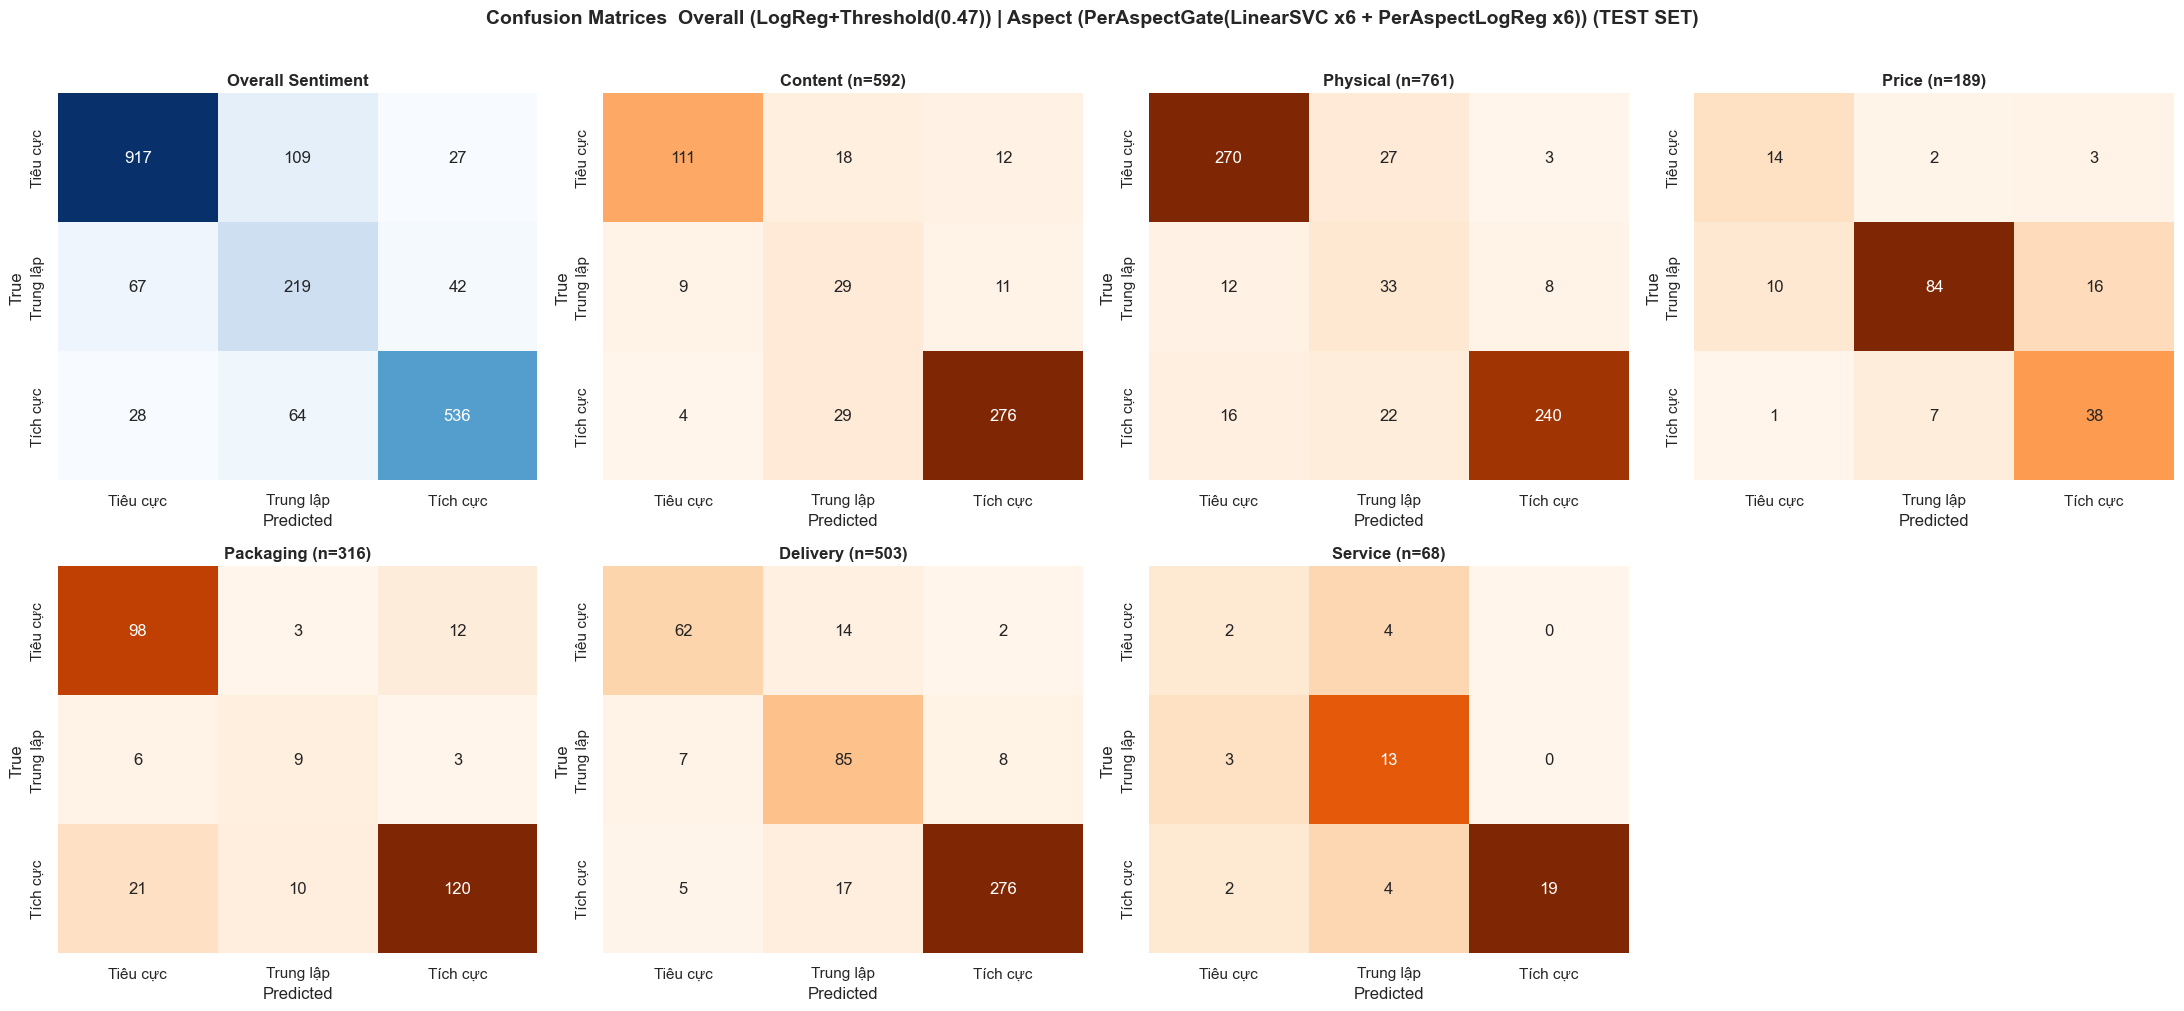

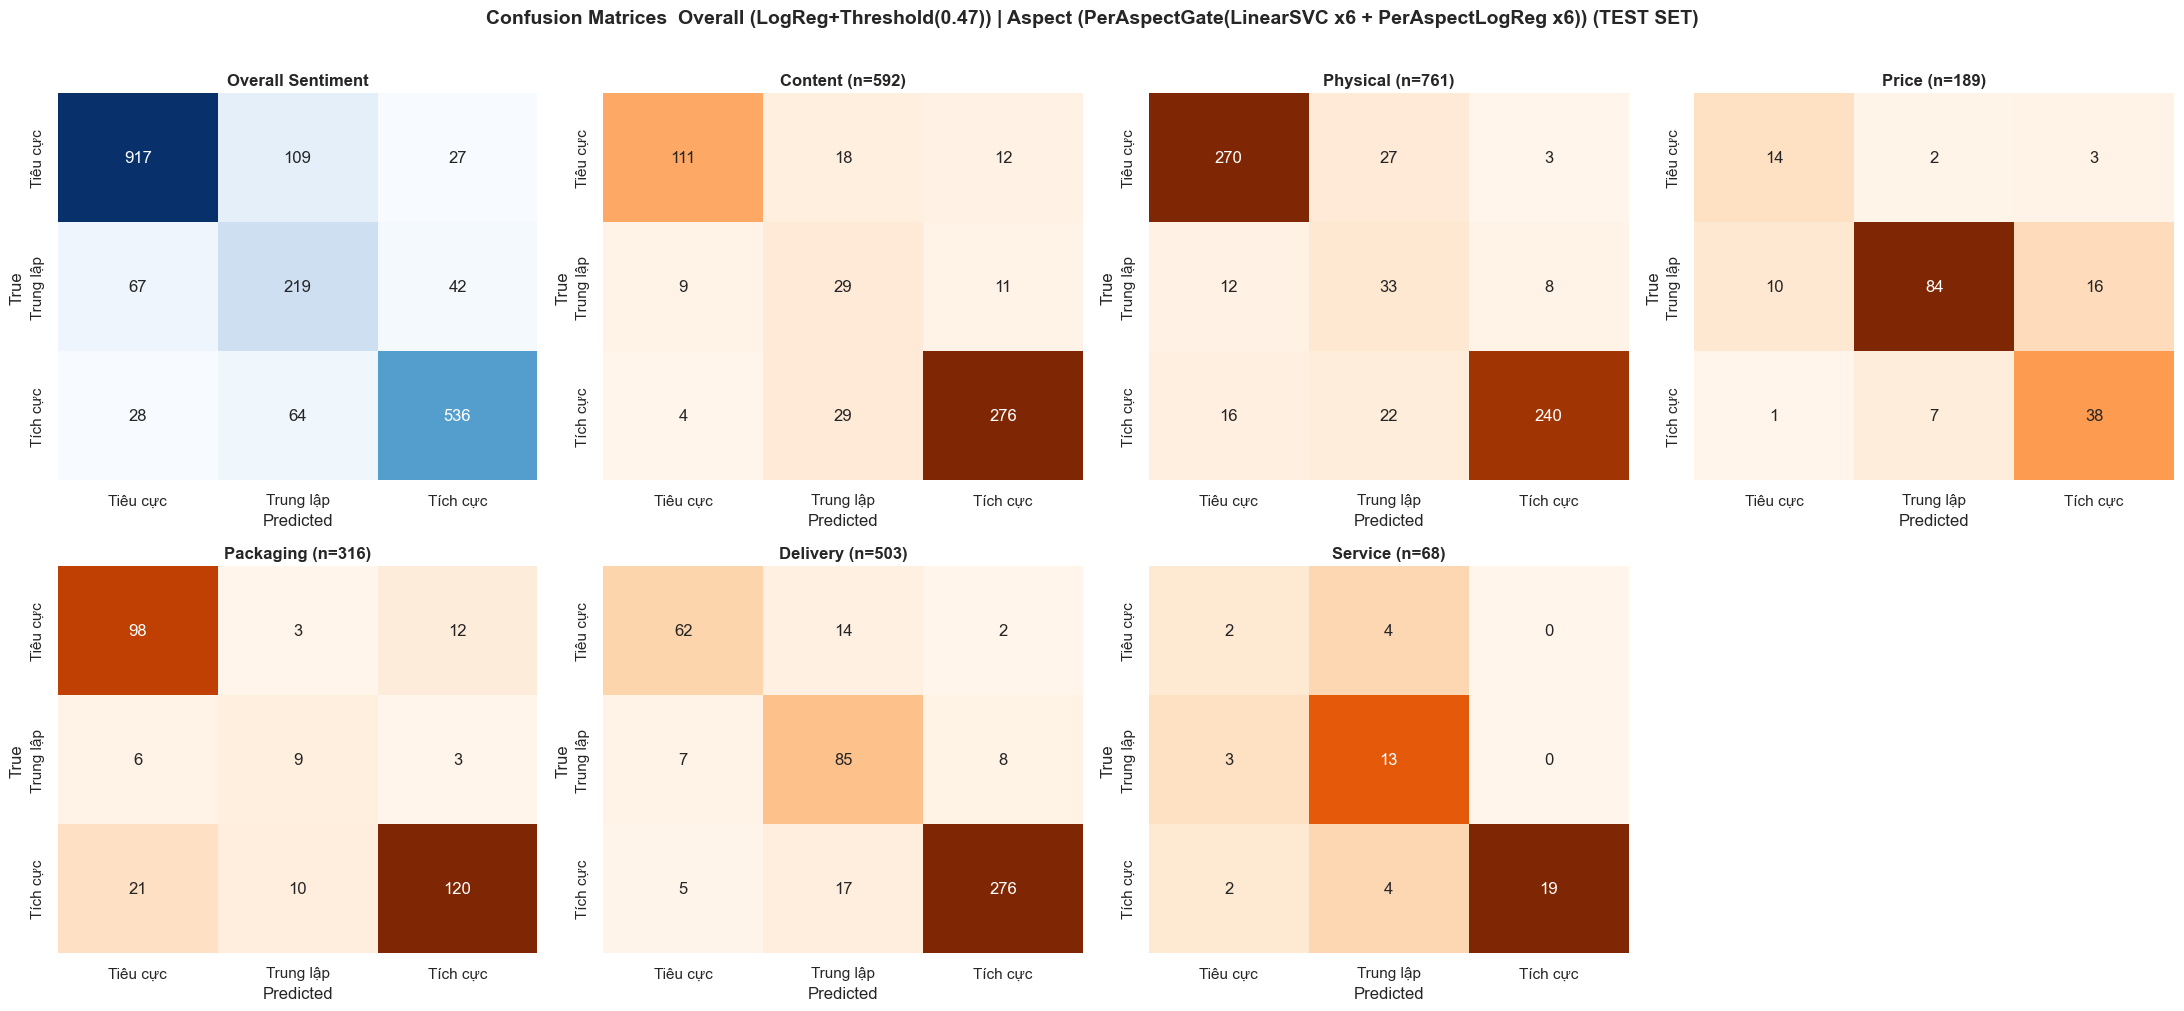

In [57]:
SENTIMENT_TEXT_TO_ID = {v: k for k, v in SENTIMENT_ID_TO_TEXT.items()}
true_sent = np.array([SENTIMENT_TEXT_TO_ID[x] for x in y_sent_test], dtype=int)
pred_sent = np.array([SENTIMENT_TEXT_TO_ID[x] for x in best_overall_pred_test], dtype=int)
true_asps = np.asarray(df_test[ASPECT_COLS].fillna(3), dtype=int)
pred_asps = np.array([SENTIMENT_TEXT_TO_ID.get(x, 3) for x in best_asp_pred_test], dtype=int).reshape(len(ASPECT_COLS), len(df_test)).T

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
NAMES = ['Tiêu cực', 'Trung lập', 'Tích cực']
ASP_DISPLAY = ['Content', 'Physical', 'Price', 'Packaging', 'Delivery', 'Service']

cm_sent = confusion_matrix(true_sent, pred_sent, labels=[0, 1, 2])
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues',
            xticklabels=NAMES, yticklabels=NAMES, ax=axes[0], cbar=False)
axes[0].set_title('Overall Sentiment', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

for j, (col, disp) in enumerate(zip(ASPECT_COLS, ASP_DISPLAY)):
    ax = axes[j + 1]
    idx = ASPECT_COLS.index(col)
    tc = true_asps[:, idx]
    pc = pred_asps[:, idx]
    mask = tc != 3
    if not mask.any():
        ax.set_visible(False)
        continue
    cm_asp = confusion_matrix(tc[mask], pc[mask], labels=[0, 1, 2])
    sns.heatmap(cm_asp, annot=True, fmt='d', cmap='Oranges',
                xticklabels=NAMES, yticklabels=NAMES, ax=ax, cbar=False)
    ax.set_title(f'{disp} (n={mask.sum()})', fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

if len(axes) > 7:
    axes[7].set_visible(False)

plt.suptitle(f'Confusion Matrices  Overall ({best_overall_method}) | Aspect ({best_asp_method}) (TEST SET)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
display(fig)
plt.show()


## 12. Lưu Artifacts

Lưu model, vectorizer, features pipeline, predictions, metrics và config.


In [58]:
# Predictions
df_overall_pred = pd.DataFrame({
    "review_id": df_test["review_id"],
    "y_true": y_sent_test,
    "y_pred": best_overall_pred_test,
})
df_overall_pred.to_csv(ARTIFACT_DIR / "overall_predictions_test.csv", index=False)

df_aspect_pred = df_as_test[["review_id", "aspect", "label"]].copy()
df_aspect_pred["pred_label"] = best_asp_pred_test
df_aspect_pred.to_csv(ARTIFACT_DIR / "aspect_predictions_test.csv", index=False)

# Metrics
summary.to_csv(ARTIFACT_DIR / "metrics_summary.csv", index=False)
stage1_grid.to_csv(ARTIFACT_DIR / "aspect_gate_calibration.csv", index=False)
stage2_grid.to_csv(ARTIFACT_DIR / "aspect_stage2_summary.csv", index=False)

metrics = {
    "overall": {
        "best_method": best_overall_method,
        "best_val_f1": best_overall_val_f1,
        "best_test_f1": best_overall_f1,
        "methods": overall_results,
    },
    "aspect_two_stage": {
        "stage1_thresholds": best_stage1_thresholds,
        "stage1_gate_val_f1_mean": best_stage1_val_gate_f1,
        "stage1_gate_test_f1_mean": best_stage1_test_gate_f1,
        "stage1_gate_summary": json.loads(stage1_grid.round(6).to_json(orient="records")),
        "stage2_best_c_by_aspect": asp_stage2_best_c,
        "stage2_neu_threshold_by_aspect": asp_stage2_neu_threshold,
        "stage2_present_val_f1_by_aspect": asp_stage2_present_val_f1,
        "stage2_present_test_f1_by_aspect": asp_stage2_present_test_f1,
        "stage2_present_val_f1_mean": best_stage2_val_present_f1,
        "stage2_present_test_f1_mean": best_stage2_test_present_f1,
        "stage2_summary": json.loads(stage2_grid.round(6).to_json(orient="records")),
        "val_present_f1": val_aspect_present_f1,
        "test_present_f1": test_aspect_present_f1,
    },
    "val_f1_final": val_f1_final,
    "f1_final": f1_final,
}
(ARTIFACT_DIR / "metrics.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")

# Config
config = {
    "project_root": str(PROJECT_ROOT),
    "tfidf_overall": {k: (list(v) if isinstance(v, tuple) else str(v) if callable(v) else v) for k, v in TFIDF_OVERALL_CONFIG.items()},
    "tfidf_overall_char": {k: (list(v) if isinstance(v, tuple) else str(v) if callable(v) else v) for k, v in TFIDF_OVERALL_CHAR_CONFIG.items()},
    "tfidf_aspect": {k: (list(v) if isinstance(v, tuple) else str(v) if callable(v) else v) for k, v in TFIDF_ASPECT_CONFIG.items()},
    "tfidf_aspect_char": {k: (list(v) if isinstance(v, tuple) else str(v) if callable(v) else v) for k, v in TFIDF_ASPECT_CHAR_CONFIG.items()},
    "features": list(feat_train.columns),
    "aspect_names": ASPECT_NAMES,
    "aspect_pipeline": {
        "stage1_model": "LinearSVC per-aspect",
        "stage1_thresholds": best_stage1_thresholds,
        "stage1_gate_val_f1_mean": best_stage1_val_gate_f1,
        "stage1_gate_test_f1_mean": best_stage1_test_gate_f1,
        "stage2_model": "LogisticRegression per-aspect",
        "stage2_best_c_by_aspect": asp_stage2_best_c,
        "stage2_neu_threshold_by_aspect": asp_stage2_neu_threshold,
        "stage2_present_val_f1_mean": best_stage2_val_present_f1,
        "stage2_present_test_f1_mean": best_stage2_test_present_f1,
    },
    "neutral_threshold": lr_threshold,
    "class_weight": "balanced",
}
(ARTIFACT_DIR / "config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")

# Models
joblib.dump(lr_model, ARTIFACT_DIR / "overall_logreg.joblib")
joblib.dump(svc_model, ARTIFACT_DIR / "overall_svc.joblib")
joblib.dump(tfidf_overall, ARTIFACT_DIR / "overall_tfidf.joblib")
joblib.dump(tfidf_overall_char, ARTIFACT_DIR / "overall_tfidf_char.joblib")
joblib.dump(tfidf_aspect_word, ARTIFACT_DIR / "aspect_tfidf_word.joblib")
joblib.dump(tfidf_aspect_char, ARTIFACT_DIR / "aspect_tfidf_char.joblib")
joblib.dump(asp_stage1_models, ARTIFACT_DIR / "aspect_stage1_gates.joblib")
joblib.dump({
    "models": asp_stage2_models,
    "best_c_by_aspect": asp_stage2_best_c,
    "neu_threshold_by_aspect": asp_stage2_neu_threshold,
    "present_val_f1_by_aspect": asp_stage2_present_val_f1,
    "present_test_f1_by_aspect": asp_stage2_present_test_f1,
}, ARTIFACT_DIR / "aspect_stage2_sentiment.joblib")

print()
print(f"Artifacts saved at: {ARTIFACT_DIR}")



Artifacts saved at: d:\DataPreprocessing\DoAn2\artifacts\classic_ml_absa_raw_v1
